# **Census Income Prediction: Classifying Income Levels Based on Demographic Census Data**

# **Loading Files**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Loading Dataset and Cleaning**

In [ ]:

# Define column names based on dataset documentation
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Load the dataset
# Note: The dataset contains leading spaces after commas, so we use sep=', '
df = pd.read_csv('adult.data', names=columns, sep=', ', engine='python')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## **Dataset Cleaning**

In [ ]:
# 1. Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# 2. Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# 3. Drop rows with missing values (standard for this specific dataset)
df.dropna(inplace=True)

# 4. Clean the target variable (remove trailing dots if any)
df['income'] = df['income'].str.rstrip('.')

print(f"Cleaned Dataset Shape: {df.shape}")

Missing values per column:
 age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64
Cleaned Dataset Shape: (30162, 15)


# **Exploratory Data Analysis**

## **Univariate Analysis (Distribution of Features)**

/tmp/ipython-input-222471539.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, palette='Set2')
/tmp/ipython-input-222471539.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='pastel')


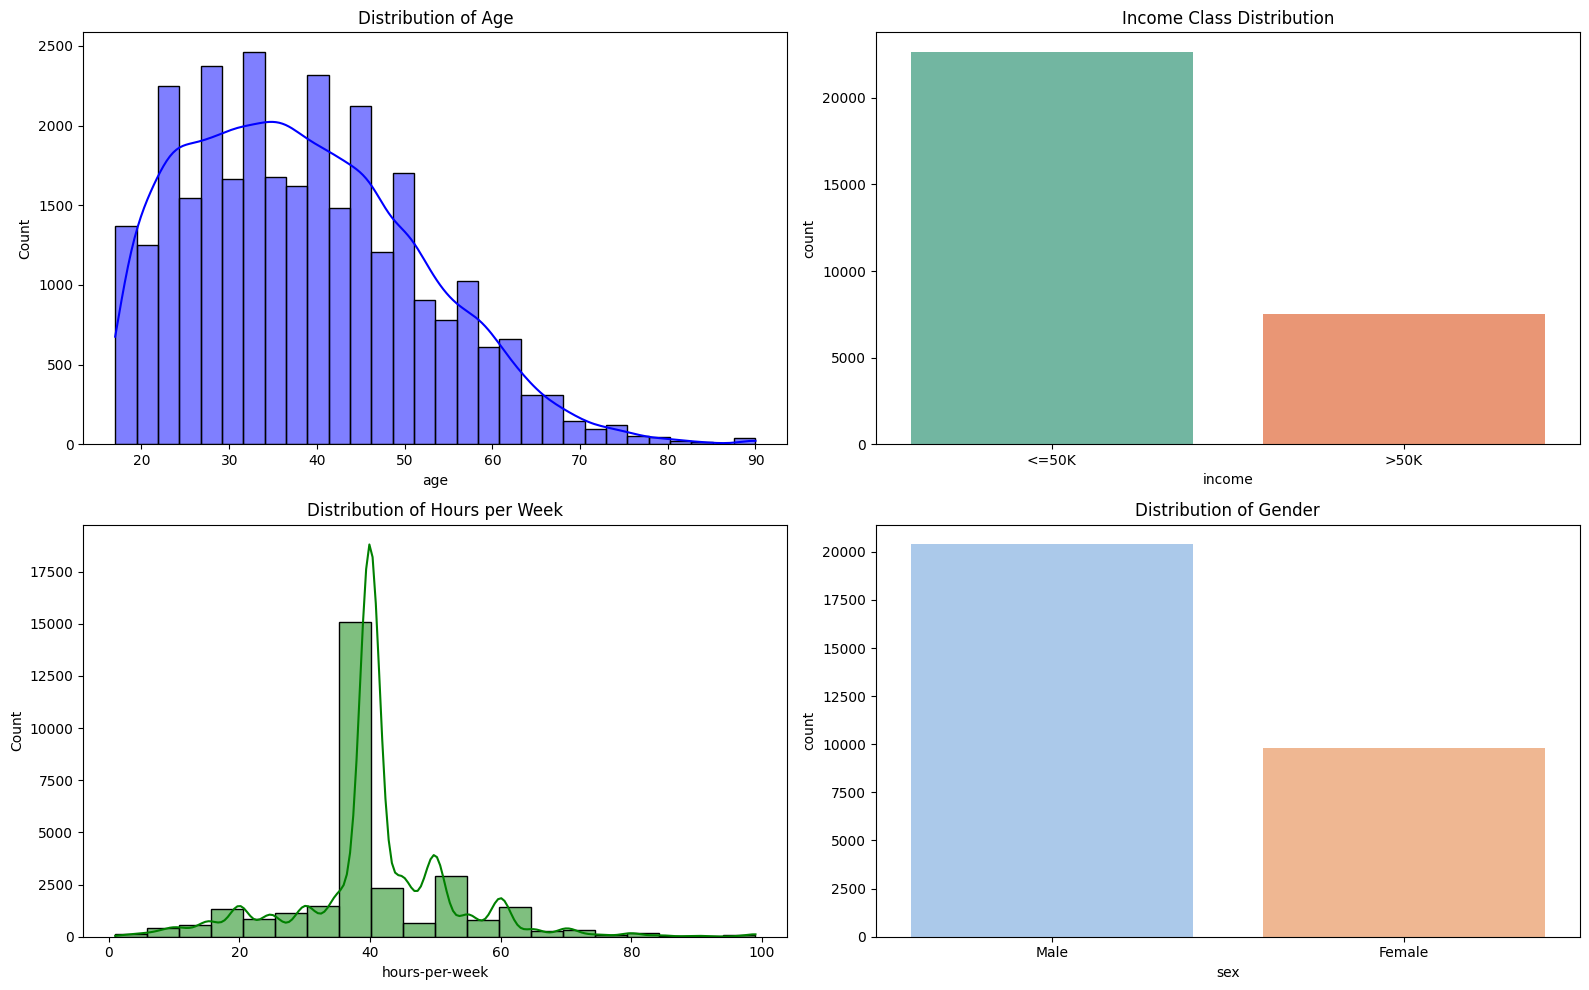

In [ ]:
plt.figure(figsize=(16, 10))

# Age Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['age'], bins=30, kde=True, color='blue')
plt.title('Distribution of Age')

# Income Distribution (Target Variable)
plt.subplot(2, 2, 2)
sns.countplot(x='income', data=df, palette='Set2')
plt.title('Income Class Distribution')

# Hours Per Week
plt.subplot(2, 2, 3)
sns.histplot(df['hours-per-week'], bins=20, kde=True, color='green')
plt.title('Distribution of Hours per Week')

# Sex Distribution
plt.subplot(2, 2, 4)
sns.countplot(x='sex', data=df, palette='pastel')
plt.title('Distribution of Gender')

plt.tight_layout()
plt.show()

## **Bivariate Analysis (Relationships with Income)**

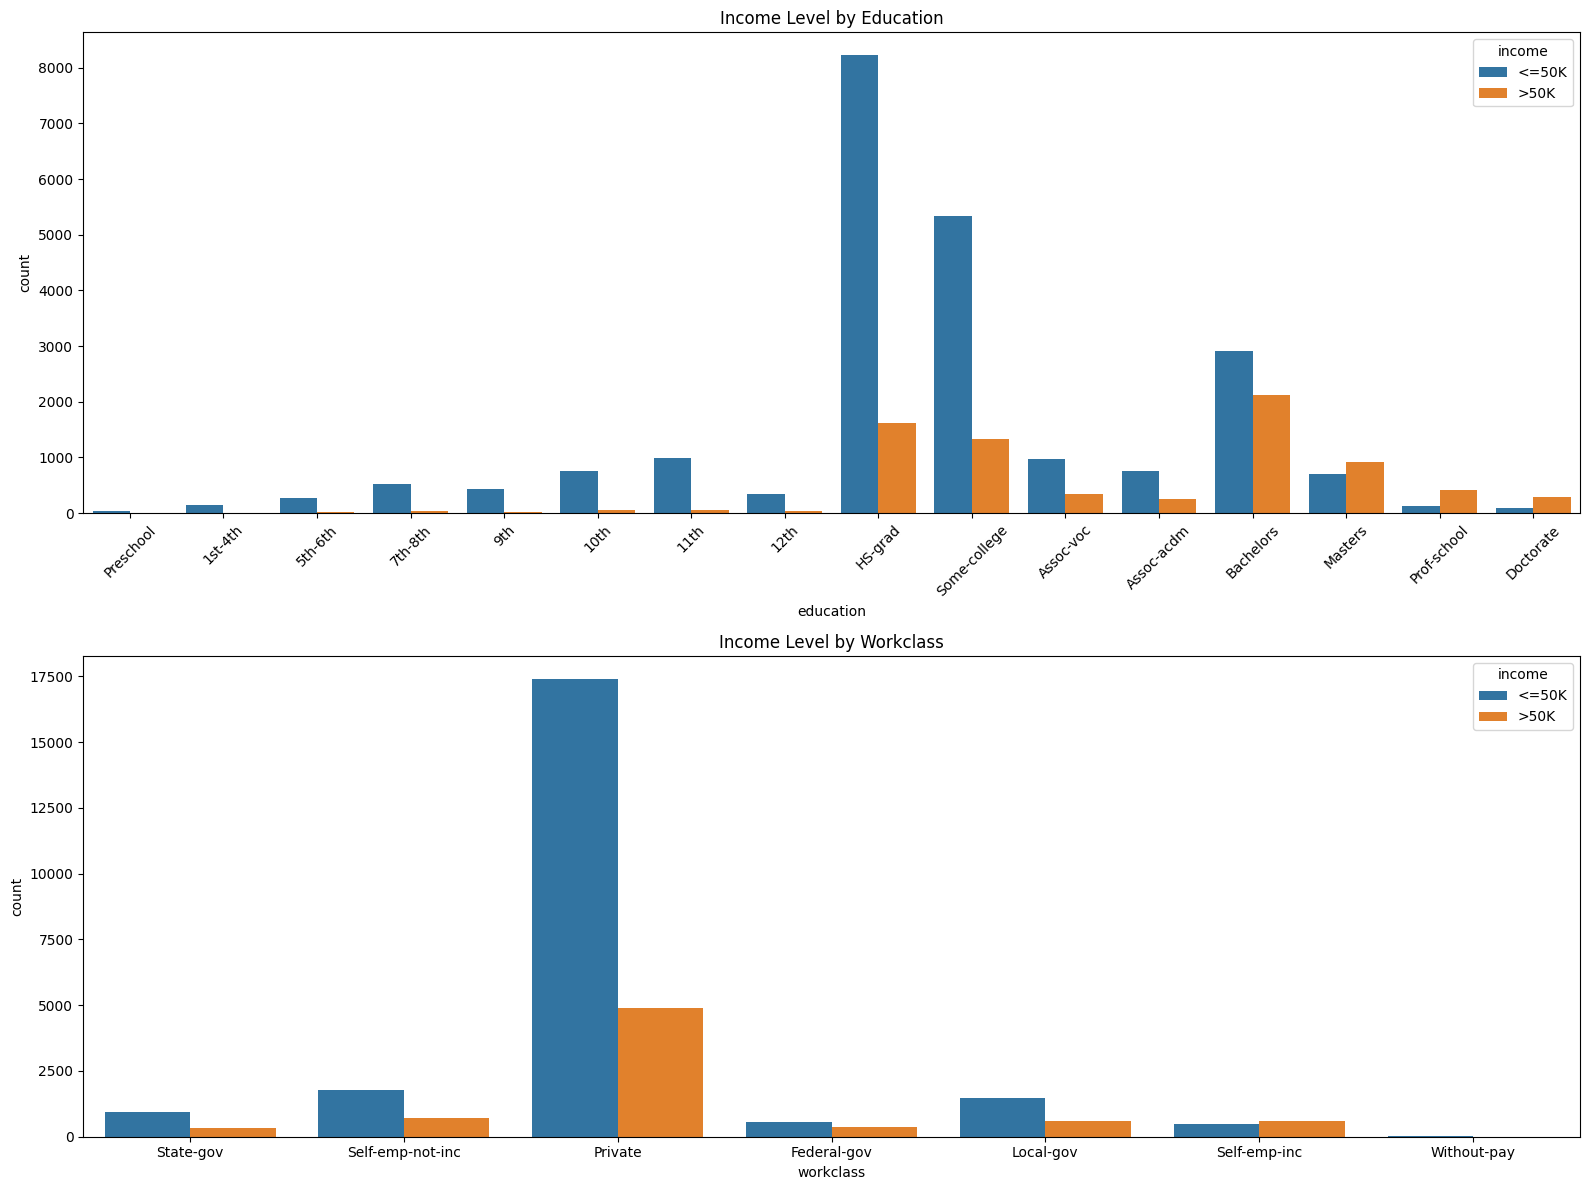

In [ ]:
plt.figure(figsize=(16, 12))

# Education vs Income
plt.subplot(2, 1, 1)
# Sorting by education-num ensures the levels are in order (e.g., HS-grad < Bachelors)
order = df.groupby('education')['education-num'].mean().sort_values().index
sns.countplot(x='education', hue='income', data=df, order=order)
plt.xticks(rotation =45)
plt.title('Income Level by Education')

# Workclass vs Income
plt.subplot(2, 1, 2)
sns.countplot(x='workclass', hue='income', data=df)
plt.title('Income Level by Workclass')

plt.tight_layout()
plt.show()

## **Numerical Correlations**

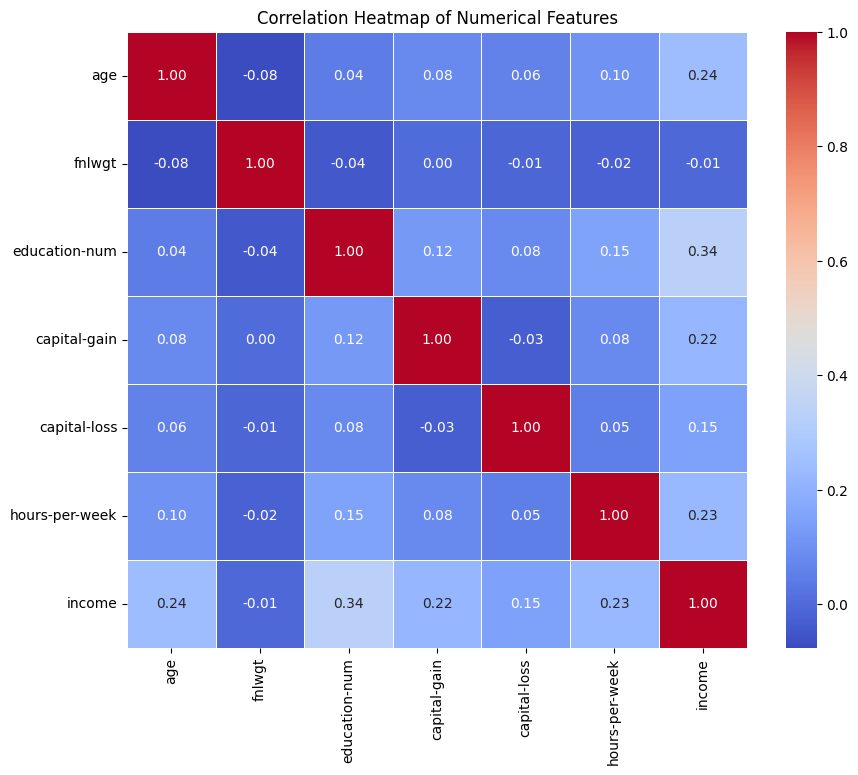

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy for correlation analysis
df_corr = df.copy()
# Encode income to numeric: <=50K is 0, >50K is 1
df_corr['income'] = df_corr['income'].map({'<=50K': 0, '>50K': 1})

# Select only numerical columns for correlation calculation
numeric_cols = df_corr.select_dtypes(include=np.number).columns

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## **Multivariate Analysis (Hours vs. Age vs. Income)**

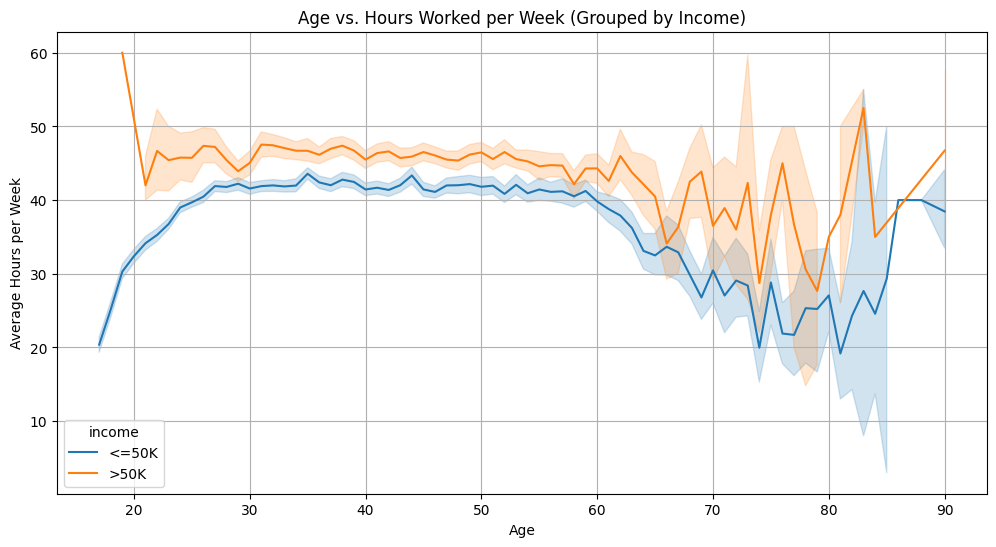

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='age', y='hours-per-week', hue='income', data=df)
plt.title('Age vs. Hours Worked per Week (Grouped by Income)')
plt.xlabel('Age')
plt.ylabel('Average Hours per Week')
plt.grid(True)
plt.show()